# Etapa 3.5 — Seleção de k* e Recomendação

Consolida os resultados do teste de equivalência estatística (3.4) para selecionar k* e a arquitetura recomendada para a Etapa 4.

## Seção 1 — Imports e carga dos resultados

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/Users/lorenzoferreira/Documents/UFRGS/TCC_SBO")
ETAPA_3      = PROJECT_ROOT / "ARTEFATOS" / "ETAPA_3"
OUT_DIR      = ETAPA_3 / "3.5_RANKING_FINAL"
EQUIV_CSV    = ETAPA_3 / "3.4_EQUIVALENCIA" / "3.4_equivalencia_resultados.csv"
SUBCONJ_CSV  = ETAPA_3 / "3.2_FEAT_SELECTION" / "3.2_subconjuntos.csv"
SHAP_CSV     = ETAPA_3 / "3.1_SHAP" / "3.1_shap_consolidado.csv"

df = pd.read_csv(EQUIV_CSV)
subconj = pd.read_csv(SUBCONJ_CSV)
shap_df = pd.read_csv(SHAP_CSV)

print(f"Equivalência: {len(df)} linhas, colunas: {list(df.columns)}")
print(f"Subconjuntos: {len(subconj)} linhas")
print(f"SHAP consolidado: {len(shap_df)} linhas")
assert len(df) == 45, f"Esperado 45 linhas, obtido {len(df)}"
assert df["equivalente"].notna().all(), "Coluna 'equivalente' contém NaN"
print("\nIntegridade OK.")

Equivalência: 45 linhas, colunas: ['arquitetura', 'output', 'k', 'r2_8', 'r2_k', 'delta_r2', 'delta_r2_boot_medio', 'ic_inf', 'ic_sup', 'equivalente']
Subconjuntos: 3 linhas
SHAP consolidado: 120 linhas

Integridade OK.


In [2]:
# Mapeamento k → lista de features (da Etapa 3.2)
def parse_features(s):
    return [f.strip() for f in s.split(",")]

subconj_dict = {}
for _, row in subconj.iterrows():
    subconj_dict[int(row["k"])] = parse_features(row["features"])

print("Subconjuntos:")
for k, feats in subconj_dict.items():
    print(f"  S_{k}: {feats}")

Subconjuntos:
  S_4: ['BRC1', 'RRC1', 'RFF', 'RRC2']
  S_5: ['BRC1', 'RRC1', 'RFF', 'RRC2', 'T1']
  S_6: ['T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']


## Seção 2 — Critério de seleção de k*

Critérios aplicados em ordem:
1. **Filtro de equivalência:** (arquitetura, k) equivalente nos **três outputs simultaneamente**.
2. **Preferência por menor k:** entre os k que satisfazem (1), escolher o menor.
3. **Desempate em k:** arquitetura com maior R²_k médio nos três outputs.

In [3]:
OUTPUTS = ["ET", "M_CH3OH", "x_CH3OH"]

# Critério 1: equivalente nos 3 outputs simultaneamente
equiv_global = (
    df.groupby(["arquitetura", "k"])
    .agg(
        n_outputs=("output", "count"),
        n_equiv=("equivalente", "sum"),
        r2k_medio=("r2_k", "mean"),
    )
    .reset_index()
)
equiv_global["equiv_global"] = equiv_global["n_equiv"] == 3

passing = equiv_global[equiv_global["equiv_global"]].copy()
print(f"Combinações (arquitetura, k) com equivalência nos 3 outputs: {len(passing)}")
print(passing[["arquitetura", "k", "n_equiv", "r2k_medio"]].to_string(index=False))

Combinações (arquitetura, k) com equivalência nos 3 outputs: 3
arquitetura  k  n_equiv  r2k_medio
         DT  6        3   0.826884
         RF  6        3   0.917942
        SVR  6        3   0.972254


In [4]:
# Critério 2: menor k entre os que passaram
if len(passing) == 0:
    print("ATENÇÃO: Nenhuma combinação passou — activando fallback (Seção 4).")
    k_estrela = None
    arq_recomendada = None
else:
    k_estrela = int(passing["k"].min())
    candidatos_k = passing[passing["k"] == k_estrela]
    print(f"k* = {k_estrela}")
    print(f"Arquiteturas elegíveis com k={k_estrela}:")
    print(candidatos_k[["arquitetura", "r2k_medio"]].to_string(index=False))

    # Critério 3: maior R²_k médio
    arq_recomendada = candidatos_k.loc[
        candidatos_k["r2k_medio"].idxmax(), "arquitetura"
    ]
    print(f"\nArquitetura recomendada: {arq_recomendada} (maior R²_k médio)")

k* = 6
Arquiteturas elegíveis com k=6:
arquitetura  r2k_medio
         DT   0.826884
         RF   0.917942
        SVR   0.972254

Arquitetura recomendada: SVR (maior R²_k médio)


## Seção 3 — Resultado: S_k* e persistência do artefato canônico

In [5]:
if k_estrela is not None:
    S_k_estrela = subconj_dict[k_estrela]

    # Métricas da arquitetura recomendada
    mask_arq = (df["arquitetura"] == arq_recomendada) & (df["k"] == k_estrela)
    metricas_arq = df[mask_arq][["output", "r2_8", "r2_k", "delta_r2", "ic_inf", "ic_sup", "equivalente"]]

    r2k_medio_arq = float(df[mask_arq]["r2_k"].mean())

    justificativa = (
        f"k={k_estrela} é o menor k com equivalência simultânea nos 3 outputs; "
        f"{arq_recomendada} tem maior R²_k médio ({r2k_medio_arq:.4f}) "
        f"entre as arquiteturas elegíveis"
    )

    resultado = {
        "k_estrela": k_estrela,
        "S_k_estrela": S_k_estrela,
        "arquitetura_recomendada": arq_recomendada,
        "r2k_medio": round(r2k_medio_arq, 6),
        "justificativa": justificativa,
    }

    out_json = OUT_DIR / "3.5_k_estrela.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(resultado, f, ensure_ascii=False, indent=2)

    print("=== RESULTADO FINAL ===")
    print(f"k* = {k_estrela}")
    print(f"S_k* = {S_k_estrela}")
    print(f"Arquitetura recomendada: {arq_recomendada}")
    print(f"R²_k médio (3 outputs): {r2k_medio_arq:.4f}")
    print(f"Justificativa: {justificativa}")
    print(f"\nSalvo em: {out_json}")
    print("\nMétricas da arquitetura recomendada:")
    print(metricas_arq.to_string(index=False))

=== RESULTADO FINAL ===
k* = 6
S_k* = ['T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
Arquitetura recomendada: SVR
R²_k médio (3 outputs): 0.9723
Justificativa: k=6 é o menor k com equivalência simultânea nos 3 outputs; SVR tem maior R²_k médio (0.9723) entre as arquiteturas elegíveis

Salvo em: reduzido/3.5_k_estrela.json

Métricas da arquitetura recomendada:
 output     r2_8     r2_k  delta_r2    ic_inf    ic_sup  equivalente
M_CH3OH 0.983139 0.976403  0.006736 -0.000125  0.015121         True
x_CH3OH 0.953070 0.968416 -0.015346 -0.031647 -0.001131         True
     ET 0.970118 0.971942 -0.001824 -0.010566  0.005811         True


## Seção 4 — Cenário de fallback (nenhum k equivalente globalmente)

In [6]:
if k_estrela is None:
    print("Fallback ativado: nenhuma (arquitetura, k) é equivalente nos 3 outputs.")
    print()

    # Tentar granularidade por output (D-E3-04 reaberta)
    print("Tentando granularidade por output:")
    equiv_por_output = df[df["equivalente"]]
    for output in OUTPUTS:
        melhores = equiv_por_output[equiv_por_output["output"] == output]
        if len(melhores) > 0:
            melhor = melhores.loc[melhores["r2_k"].idxmax()]
            print(f"  {output}: {melhor['arquitetura']} k={melhor['k']} R²={melhor['r2_k']:.4f}")
        else:
            print(f"  {output}: nenhum equivalente — H1 rejeitada para este output")

    # Fallback final: melhor (arquitetura, k) por R²_k médio global
    best_idx = equiv_global.loc[equiv_global["r2k_medio"].idxmax()]
    print(f"\nFallback final: {best_idx['arquitetura']} k={int(best_idx['k'])} "
          f"(R²_k médio={best_idx['r2k_medio']:.4f})")
    print("H1 parcialmente rejeitada — registrar como limitação no TCC.")
else:
    print("Fallback não necessário — k* determinado na Seção 2.")

Fallback não necessário — k* determinado na Seção 2.


## Seção 5 — Síntese visual

### 5a — Tabela de equivalência: arquitetura × output × k

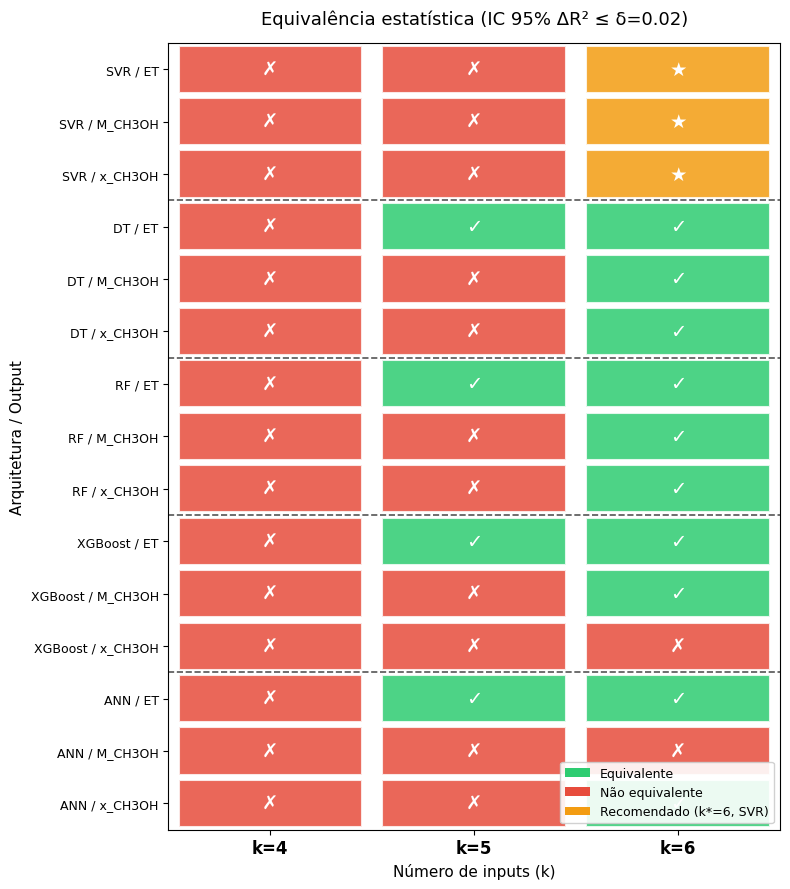

Salvo: reduzido/3.5_tabela_final.png


In [7]:
ARQUITETURAS = ["SVR", "DT", "RF", "XGBoost", "ANN"]
KS = [4, 5, 6]

# Pivot: índice = (arquitetura, output), colunas = k
pivot = df.pivot_table(
    index=["arquitetura", "output"], columns="k", values="equivalente", aggfunc="first"
)
# Reordenar
ordered_idx = [(a, o) for a in ARQUITETURAS for o in OUTPUTS]
pivot = pivot.reindex(ordered_idx)

fig, ax = plt.subplots(figsize=(8, 9))
ax.set_xlim(0, len(KS))
ax.set_ylim(0, len(ordered_idx))
ax.set_xticks(np.arange(len(KS)) + 0.5)
ax.set_xticklabels([f"k={k}" for k in KS], fontsize=12, fontweight="bold")
ax.set_yticks(np.arange(len(ordered_idx)) + 0.5)
ax.set_yticklabels(
    [f"{a} / {o}" for a, o in reversed(ordered_idx)], fontsize=9
)
ax.set_title("Equivalência estatística (IC 95% ΔR² ≤ δ=0.02)", fontsize=13, pad=14)

COLOR_SIM = "#2ecc71"
COLOR_NAO = "#e74c3c"
COLOR_K_ESTRELA = "#f39c12"

for row_i, (arq, out) in enumerate(reversed(ordered_idx)):
    for col_i, k in enumerate(KS):
        val = pivot.loc[(arq, out), k]
        is_k_estrela = (k_estrela is not None and k == k_estrela
                        and arq == arq_recomendada)
        if val:
            color = COLOR_K_ESTRELA if is_k_estrela else COLOR_SIM
            symbol = "★" if is_k_estrela else "✓"
        else:
            color = COLOR_NAO
            symbol = "✗"

        rect = plt.Rectangle(
            (col_i + 0.05, row_i + 0.05), 0.9, 0.9,
            facecolor=color, edgecolor="white", linewidth=1.5, alpha=0.85,
        )
        ax.add_patch(rect)
        ax.text(
            col_i + 0.5, row_i + 0.5, symbol,
            ha="center", va="center", fontsize=14, color="white", fontweight="bold",
        )

# Linhas separadoras entre arquiteturas
n_out = len(OUTPUTS)
for i in range(1, len(ARQUITETURAS)):
    ax.axhline(i * n_out, color="#555", linewidth=1.2, linestyle="--")

# Legenda
legend_patches = [
    mpatches.Patch(facecolor=COLOR_SIM, label="Equivalente"),
    mpatches.Patch(facecolor=COLOR_NAO, label="Não equivalente"),
    mpatches.Patch(facecolor=COLOR_K_ESTRELA, label=f"Recomendado (k*={k_estrela}, {arq_recomendada})"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9, framealpha=0.9)

ax.set_xlabel("Número de inputs (k)", fontsize=11)
ax.set_ylabel("Arquitetura / Output", fontsize=11)
plt.tight_layout()
out_tabela = OUT_DIR / "3.5_tabela_final.png"
plt.savefig(out_tabela, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvo: {out_tabela}")

### 5b — Ranking SHAP final destacando S_k*

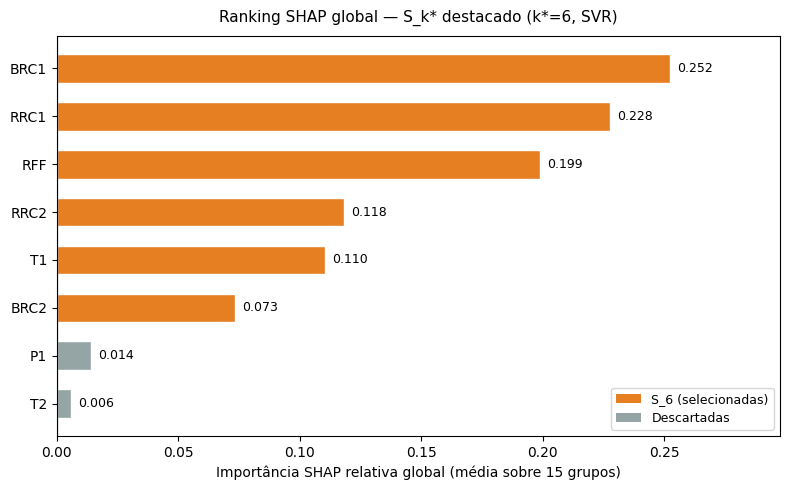

Salvo: reduzido/3.5_ranking_final.png


In [8]:
# Importância global: média do |SHAP| médio normalizado por (modelo, output)
shap_df["shap_rel"] = shap_df.groupby(["modelo", "output"])["shap_mean"].transform(
    lambda x: x / x.sum()
)
importancia_global = (
    shap_df.groupby("feature")["shap_rel"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
importancia_global.columns = ["feature", "importancia_global"]

S_k_estrela_set = set(S_k_estrela if k_estrela else [])

# Cores: laranja = em S_k*, cinza = descartada
colors = [
    "#e67e22" if f in S_k_estrela_set else "#95a5a6"
    for f in importancia_global["feature"]
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    importancia_global["feature"][::-1],
    importancia_global["importancia_global"][::-1],
    color=list(reversed(colors)),
    edgecolor="white",
    height=0.6,
)

for bar, val in zip(bars, importancia_global["importancia_global"][::-1]):
    ax.text(
        bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center", ha="left", fontsize=9,
    )

ax.set_xlabel("Importância SHAP relativa global (média sobre 15 grupos)", fontsize=10)
ax.set_title(
    f"Ranking SHAP global — S_k* destacado (k*={k_estrela}, {arq_recomendada})",
    fontsize=11, pad=10,
)

legend_patches = [
    mpatches.Patch(facecolor="#e67e22", label=f"S_{k_estrela} (selecionadas)"),
    mpatches.Patch(facecolor="#95a5a6", label="Descartadas"),
]
ax.legend(handles=legend_patches, fontsize=9, loc="lower right")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(0, importancia_global["importancia_global"].max() * 1.18)

plt.tight_layout()
out_ranking = OUT_DIR / "3.5_ranking_final.png"
plt.savefig(out_ranking, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvo: {out_ranking}")

## Seção 6 — Validação e resumo executivo

In [9]:
FEATURES_ORIGINAIS = {"P1", "T1", "T2", "RRC1", "BRC1", "RRC2", "BRC2", "RFF"}

checklist = []

# 1. JSON existe
json_ok = out_json.exists()
checklist.append(("3.5_k_estrela.json existe", json_ok))

# 2. Inputs em S_k* pertencem ao conjunto original
if k_estrela is not None:
    inputs_ok = set(S_k_estrela).issubset(FEATURES_ORIGINAIS)
else:
    inputs_ok = False
checklist.append(("Inputs de S_k* ⊆ features originais", inputs_ok))

# 3. k* é inteiro em {4, 5, 6}
k_ok = k_estrela in {4, 5, 6} if k_estrela is not None else False
checklist.append(("k* ∈ {4, 5, 6}", k_ok))

# 4. Tabela final gerada
tabela_ok = out_tabela.exists()
checklist.append(("3.5_tabela_final.png gerado", tabela_ok))

# 5. Ranking final gerado
ranking_ok = out_ranking.exists()
checklist.append(("3.5_ranking_final.png gerado", ranking_ok))

print("=" * 52)
print("CHECKLIST DE VALIDAÇÃO — ETAPA 3.5")
print("=" * 52)
for descr, ok in checklist:
    status = "PASSOU" if ok else "FALHOU"
    print(f"  [{status}] {descr}")
n_passou = sum(ok for _, ok in checklist)
print(f"\nResultado: {n_passou}/{len(checklist)} itens aprovados")

print()
print("=" * 52)
print("RESUMO EXECUTIVO — D-E3-10")
print("=" * 52)
if k_estrela is not None:
    print(f"k* = {k_estrela}")
    print(f"S_k* = {S_k_estrela}")
    print(f"Arquitetura recomendada = {arq_recomendada}")
    print(f"R²_k* médio (3 outputs) = {r2k_medio_arq:.4f}")
    print(f"Justificativa: {justificativa}")
    print()
    print("Métricas por output:")
    print(metricas_arq.to_string(index=False))
else:
    print("H1 parcialmente rejeitada — ver Seção 4 para detalhes.")

CHECKLIST DE VALIDAÇÃO — ETAPA 3.5
  [PASSOU] 3.5_k_estrela.json existe
  [PASSOU] Inputs de S_k* ⊆ features originais
  [PASSOU] k* ∈ {4, 5, 6}
  [PASSOU] 3.5_tabela_final.png gerado
  [PASSOU] 3.5_ranking_final.png gerado

Resultado: 5/5 itens aprovados

RESUMO EXECUTIVO — D-E3-10
k* = 6
S_k* = ['T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
Arquitetura recomendada = SVR
R²_k* médio (3 outputs) = 0.9723
Justificativa: k=6 é o menor k com equivalência simultânea nos 3 outputs; SVR tem maior R²_k médio (0.9723) entre as arquiteturas elegíveis

Métricas por output:
 output     r2_8     r2_k  delta_r2    ic_inf    ic_sup  equivalente
M_CH3OH 0.983139 0.976403  0.006736 -0.000125  0.015121         True
x_CH3OH 0.953070 0.968416 -0.015346 -0.031647 -0.001131         True
     ET 0.970118 0.971942 -0.001824 -0.010566  0.005811         True
